In [17]:
import seaborn as sns
from pathlib import Path
import time
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Ajouté pour les graphiques et la PCA

# Métriques Sklearn
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA # Ajouté pour la visualisation

# --- Importation de nos modules ---
PROJECT_FCT = Path("../maladiescardiaques").resolve()
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_FCT))

print(f"Racine du projet ajoutée au PATH: {PROJECT_FCT}")

try:
    # Importer les fonctions depuis vos fichiers .py
    from traitementDonnées import load_and_split_data, create_preprocessing_pipeline
    from training import get_models_config 
    
    print("Modules 'traitementDonnées' et 'training' importés avec succès.")
    
except ImportError as e:
    print(f"ERREUR D'IMPORTATION : {e}")
    print("Veuillez vérifier les noms de vos fichiers dans le dossier 'maladiescardiaques/'.")

Racine du projet ajoutée au PATH: C:\Users\sebdr\OneDrive\Bureau\sherbrooke\IFT 603 - Techniques d'apprentissages\ProjetSession\maladiescardiaques\maladiescardiaques
Modules 'traitementDonnées' et 'training' importés avec succès.


In [4]:
# Cellule 2: Chargement des données
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cardiaque.csv"
print(f"Chargement des données depuis: {DATA_PATH}")

data = load_and_split_data(DATA_PATH)
X_train, X_test, y_train, y_test = data

print("Données chargées et divisées.")

Chargement des données depuis: C:\Users\sebdr\OneDrive\Bureau\sherbrooke\IFT 603 - Techniques d'apprentissages\ProjetSession\maladiescardiaques\data\raw\cardiaque.csv
Variable cible 'num' encodée. Valeurs uniques : [0 1]
Données chargées. Entraînement : (242, 13), Test : (61, 13)
Données chargées et divisées.


In [5]:
# Cellule 3: Entraînement d'un seul modèle (le premier de la liste)

results = {}
configs = get_models_config()
preprocessor = create_preprocessing_pipeline()

# 1. Sélectionner uniquement le premier modèle
name, config = next(iter(configs.items())) # Récupère la première paire (nom, config)

print(f"Début de l'entraînement d'un seul modèle : {name}...")
print("-" * 60)

start_global = time.time()
start_model = time.time()
print(f"🔄 Optimisation de : {name}...")

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', config['model'])
])

search = GridSearchCV(
    full_pipeline,
    config['params'],
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0 # On met 0 pour ne pas polluer le notebook
)

search.fit(X_train, y_train)

# Stocker le meilleur modèle et son score de CV
results[name] = {
    'best_model': search.best_estimator_,
    'best_cv_score': search.best_score_ # Score F1 moyen en CV
}

end_model = time.time()
print(f"✅ Terminé : {name} (Score CV F1: {search.best_score_:.4f}) [Durée: {end_model - start_model:.2f}s]")

end_global = time.time()
print("-" * 60)
print(f"Entraînement complet terminé en {end_global - start_global:.2f} secondes.")

Début de l'entraînement d'un seul modèle : LogisticRegression...
------------------------------------------------------------
🔄 Optimisation de : LogisticRegression...
✅ Terminé : LogisticRegression (Score CV F1: 0.8224) [Durée: 8.54s]
------------------------------------------------------------
Entraînement complet terminé en 8.54 secondes.


In [6]:
# Cellule 4: Calcul des performances finales sur le Test Set

print("Calcul des performances finales sur l'ensemble de Test...")
# Nous allons stocker les scores de TOUS les modèles sur le test set

for name, res in results.items():
    model = res['best_model']
    y_pred = model.predict(X_test)
    
    # Stocker les scores finaux
    res['final_f1_score'] = f1_score(y_test, y_pred)
    res['final_accuracy'] = accuracy_score(y_test, y_pred)
    res['predictions'] = y_pred
    
    # Pour la courbe ROC
    try:
        res['proba'] = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        res['proba'] = None # Certains modèles (comme SVM sans prob=True) n'ont pas predict_proba

print("Scores finaux calculés.")

Calcul des performances finales sur l'ensemble de Test...
Scores finaux calculés.



--- Analyse détaillée du meilleur modèle : LogisticRegression ---

Rapport de Classification (Test Set):
                precision    recall  f1-score   support

No Disease (0)       0.93      0.85      0.89        33
   Disease (1)       0.84      0.93      0.88        28

      accuracy                           0.89        61
     macro avg       0.89      0.89      0.89        61
  weighted avg       0.89      0.89      0.89        61



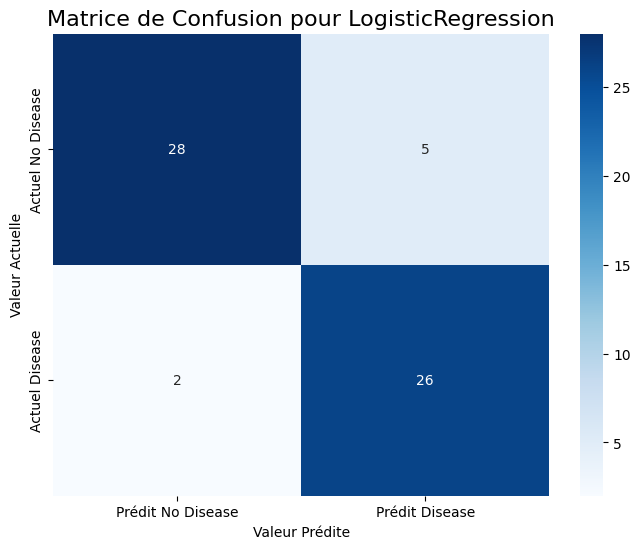

In [12]:
# Cellule 7: GRAPHIQUE 3 - Matrice de Confusion 

# Extraire les scores F1 finaux
final_scores = {name: res['final_f1_score'] for name, res in results.items()}
df_final_scores = pd.DataFrame.from_dict(
    final_scores, 
    orient='index', 
    columns=['F1_Score_Final_Test']
).sort_values(by='F1_Score_Final_Test', ascending=False)

# Trouver le meilleur modèle basé sur le score F1 final
best_model_name = df_final_scores.idxmax().values[0]
best_model_pipeline = results[best_model_name]['best_model']
y_pred_best = results[best_model_name]['predictions']

print(f"\n--- Analyse détaillée du meilleur modèle : {best_model_name} ---")

# Rapport de classification
print("\nRapport de Classification (Test Set):")
print(classification_report(y_test, y_pred_best, target_names=['No Disease (0)', 'Disease (1)']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)

# Affichage avec Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Prédit No Disease', 'Prédit Disease'],
    yticklabels=['Actuel No Disease', 'Actuel Disease']
)
plt.title(f"Matrice de Confusion pour {best_model_name}", fontsize=16)
plt.ylabel("Valeur Actuelle")
plt.xlabel("Valeur Prédite")
plt.show()


--- Visualisation 2 : Probabilités (Test Set) ---


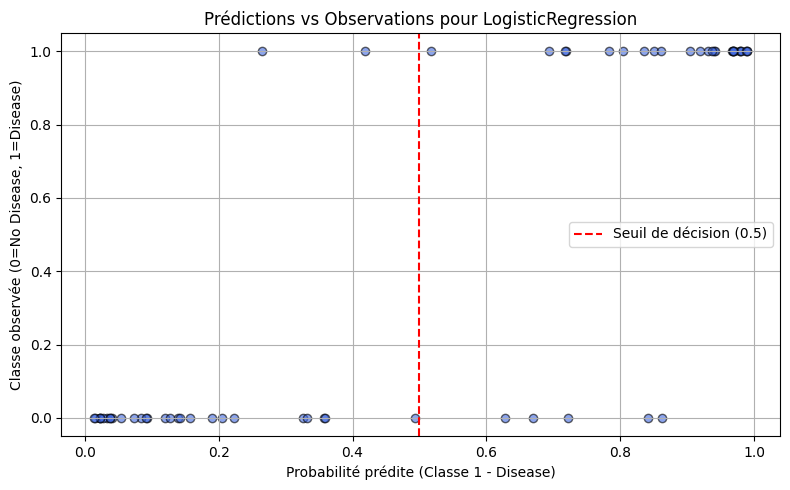

In [13]:
# Cellule 6: GRAPHIQUE 2 - Probabilités Prédites vs Observations
print(f"\n--- Visualisation 2 : Probabilités (Test Set) ---")

# Récupérer les probabilités et les vraies étiquettes
y_proba_best = results[best_model_name]['proba']

plt.figure(figsize=(8, 5))
# 'y_test' contient les vraies étiquettes de l'ensemble de test
plt.scatter(y_proba_best, y_test, alpha=0.6, color='royalblue', edgecolors='k')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Seuil de décision (0.5)')
plt.xlabel("Probabilité prédite (Classe 1 - Disease)")
plt.ylabel("Classe observée (0=No Disease, 1=Disease)")
plt.title(f"Prédictions vs Observations pour {best_model_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Visualisation 3 : Courbe ROC (Test Set) ---


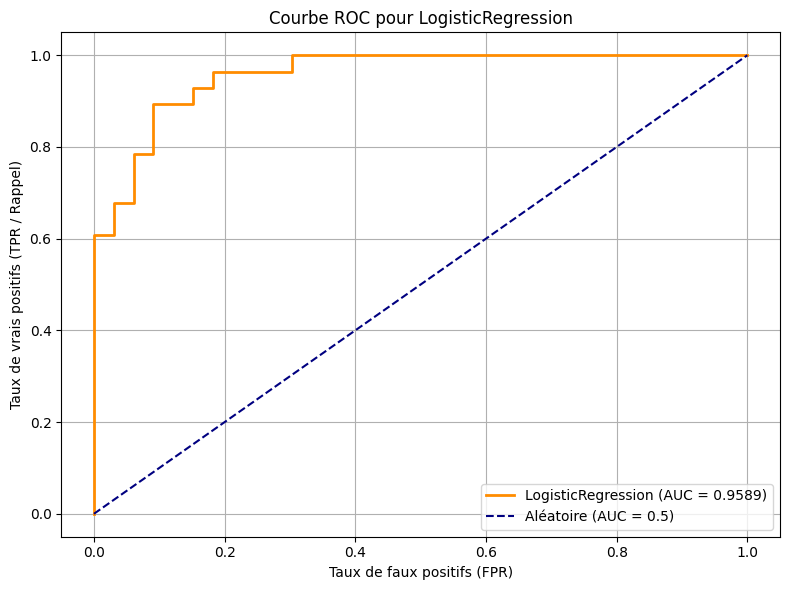

In [14]:
# Cellule 7: GRAPHIQUE 3 - Courbe ROC
print(f"\n--- Visualisation 3 : Courbe ROC (Test Set) ---")

# Calculer le FPR, TPR et l'AUC (déjà importés de sklearn)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc:.4f})", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR / Rappel)")
plt.title(f"Courbe ROC pour {best_model_name}")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Cellule 8: Fonction d'aide pour la Frontière de Décision (PCA)

def plot_decision_boundary_pca_sklearn(X_raw, y, pipeline):
    """
    Affiche la frontière de décision d'un pipeline sklearn 
    après projection des données via PCA.
    Utilise les données d'entraînement (X_raw, y) pour fitter la PCA 
    et visualiser la frontière apprise.
    """
    
    # Étape 1: Extraire les composants du pipeline
    preprocessor = pipeline.named_steps['preprocessor']
    classifier = pipeline.named_steps['classifier']
    
    # Étape 2: Appliquer le prétraitement aux données brutes
    # Note: On utilise X_train pour 'fitter' la PCA
    try:
        X_processed = preprocessor.fit_transform(X_raw)
    except Exception as e:
        print(f"Erreur lors du fit_transform du preprocessor : {e}")
        print("Assurez-vous que X_raw (X_train) a le bon format.")
        return

    # Étape 3: Réduction en 2D avec PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_processed)
    
    # Étape 4: Définition de la grille dans l'espace projeté
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    
    # Utiliser np.linspace pour une grille plus fine
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    grid_points_pca = np.c_[xx.ravel(), yy.ravel()]
    
    # Étape 5: Inversion de la projection (PCA -> Espace Prétraité)
    grid_points_processed = pca.inverse_transform(grid_points_pca)
    
    # Étape 6: Prédictions sur la grille (avec le classifieur seul)
    Z = classifier.predict(grid_points_processed)
    Z = Z.reshape(xx.shape)
    
    # Étape 7: Affichage
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # Affichage des données projetées (utilisant X_pca et y)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.RdYlBu, 
                          edgecolor='k', alpha=0.7)
    plt.xlabel("Composante principale 1")
    plt.ylabel("Composante principale 2")
    plt.title(f"Frontière de décision (sur {classifier.__class__.__name__}) via PCA")
    plt.legend(handles=scatter.legend_elements()[0], labels=['No Disease (0)', 'Disease (1)'])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Fonction 'plot_decision_boundary_pca_sklearn' définie.")

Fonction 'plot_decision_boundary_pca_sklearn' définie.



--- Visualisation 4 : Frontière de Décision (sur données d'entraînement) ---


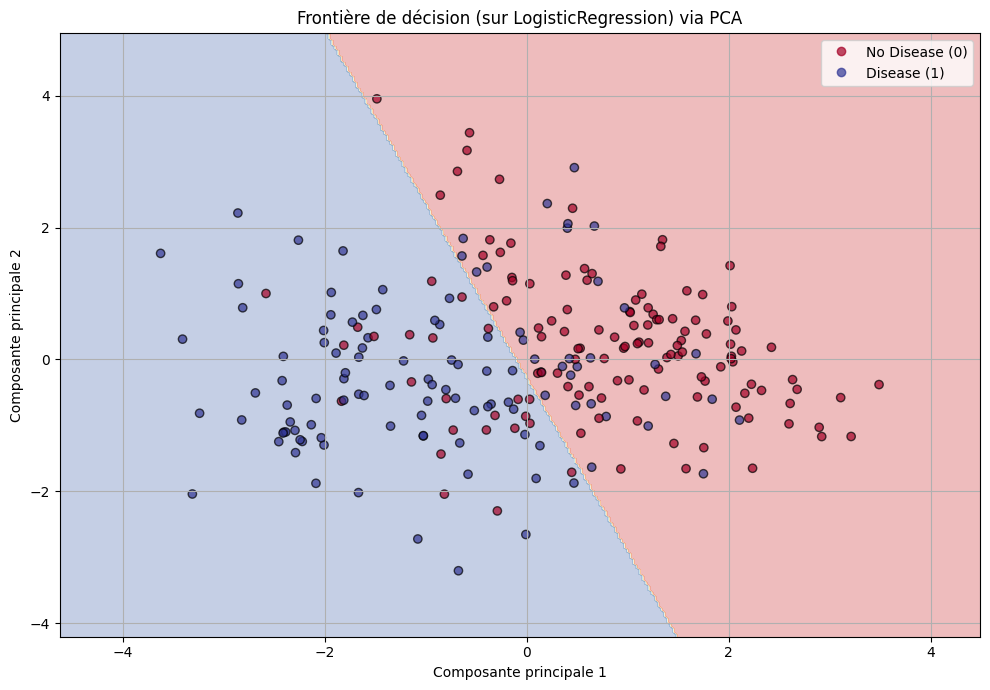

In [18]:
# Cellule 9: GRAPHIQUE 4 - Frontière de Décision (PCA)
print(f"\n--- Visualisation 4 : Frontière de Décision (sur données d'entraînement) ---")

# Note: Nous utilisons X_train et y_train pour visualiser la frontière
# que le modèle a apprise (best_model_pipeline).
# X_train est requis à l'état brut, car le pipeline gère le prétraitement.
plot_decision_boundary_pca_sklearn(X_train, y_train, best_model_pipeline)